In [1]:
from ProjectFunctions import *

In [ ]:
from scipy.signal import find

In [2]:
def staggered_magnetization(length, states):
    #will calculate the staggered magnetization opertor
    #only works for degeneracy 2
    statesigns = []
    z = Q.sigmaz()
    I = Q.qeye(2)
    for spin in states[0]:
        if spin == '0':
            sign = 1
            statesigns.append(sign)
        elif spin == '1':
            sign = -1
            statesigns.append(sign)
            
            
            
    zterm = 0
    counter = 0
    for i in range(length):
        counter += 1
        if counter % 2 != 0:
            staggersign = 1
        else:
            staggersign = -1
        # Pauli z matrix at each spin in the chain while the rest are identity
        term = Q.tensor([I] * i + [z] + [I] * (length - i - 1))
        zterm += (staggersign * term)
        #zterm += (staggersign * statesigns[i] * term)
    stagmag = (1/length) * zterm
    return stagmag

In [3]:
length = 8
hval = 0.001
jij = generate_jij(length, 14, 1)
Hint, Hintdiag = sg_interaction(length, jij)
Hfield = sg_field(length)
H = Hint + (hval * Hfield)
E, psi = H.groundstate()
Hintdiag, minenergy, degeneracy, groundpos, states = find_degeneracy(length, Hintdiag)
print(states)

['01101111', '10010000']


C:\Users\danny\anaconda3\Lib\site-packages\qutip\core\qobj.py:1626: UserWarning: Ground state may be degenerate.
  warnings.warn("Ground state may be degenerate.", UserWarning)


In [4]:
stagmag = staggered_magnetization(length, states)
#print(stagmag)
#print(psi)

In [49]:
plotlist = []
for hval in np.arange(0.001, 6, 0.1):
    H = Hint + (hval * Hfield)
    E, psi = H.groundstate()
    expectvalue = Q.expect((stagmag**2), psi)
    plotlist.append(expectvalue)

In [50]:
%%time
hvals = np.arange(0.001, 6, 0.1)
alldist = {}
allminfo = {}
# Generate all possible pairs of positions
for h in hvals:
    distancelist = []
    minfolist = []
    H = Hint + (h * Hfield)
    E, psi = H.groundstate()
    for i in range(length):
        for j in range(i + 1, length):
            combinations, physdist, minfo, distance = mutual_info(length, psi, [i], [j])
            distancelist.append(distance)
            minfolist.append(minfo)
    alldist.update({h:distancelist})
    allminfo.update({h:minfolist})
#print(alldist)
ratiodict, maxh, maxratio, stdevdict, meandict = max_variance_ratio(alldist, hvals)

CPU times: total: 1min 7s
Wall time: 17.4 s


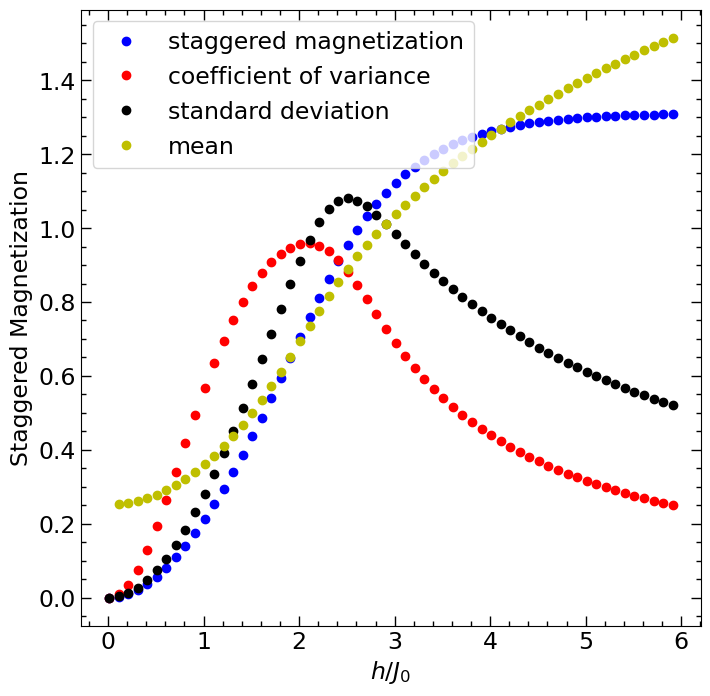

In [67]:
fig, ax = plt.subplots(figsize=(8,8))
plt.rcParams.update({'font.size': 17})
# label the axes
ax.set_xlabel(r"$h/J_0$")
ax.set_ylabel(r"Staggered Magnetization")

# set the tick mark parameters
ax.minorticks_on()
ax.tick_params(which='both',direction="in",width=1)
ax.tick_params(which='major',length=7)
ax.tick_params(which='minor',length=3.5)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

values1 = []
for key in ratiodict.keys():
    values1.append(ratiodict[key])
    
values2 = []
for key in stdevdict.keys():
    values2.append(stdevdict[key])
    
values3 = []
for key in meandict.keys():
    values3.append(meandict[key])
    
    
newvalues1 = []
for val in plotlist:
    newvalues1.append(val*10)
        
newvalues2 = []
for val in values1:
    newvalues2.append(val*2)
        
newvalues3 = []
for val in values2:
    newvalues3.append(val*1)
        
newvalues4 = []
for val in values3:
    newvalues4.append(val/2.75)

# p1 = plt.plot(np.arange(0.01, 6, 0.1), plotlist, 'ob', label = 'staggered magnetization')
# p2 = plt.plot(np.arange(0.01, 6, 0.1), values1, 'or', label = 'coefficient of variance')
# p3 = plt.plot(np.arange(0.01, 6, 0.1), values2, 'ok', label = 'standard deviation')
# p4 = plt.plot(np.arange(0.11, 6, 0.1), values3[-59:], 'oy', label = 'mean')
p1 = plt.plot(np.arange(0.01, 6, 0.1), newvalues1, 'ob', label = 'staggered magnetization')
p2 = plt.plot(np.arange(0.01, 6, 0.1), newvalues2, 'or', label = 'coefficient of variance')
p3 = plt.plot(np.arange(0.01, 6, 0.1), newvalues3, 'ok', label = 'standard deviation')
p4 = plt.plot(np.arange(0.11, 6, 0.1), newvalues4[-59:], 'oy', label = 'mean')
plt.legend()
#plt.savefig("Degen 4 Glass Model Ratio With Varied h New.pdf")
plt.show()

In [83]:
newlist = newvalues4[-59:]
# Calculate numerical derivatives (slope between adjacent points)
dx = np.diff(np.arange(0.11, 6, 0.1))
dy = np.diff(newlist)
slopes = dy / dx

# Find the index of the maximum slope
max_slope_index = np.argmax(np.abs(slopes))

# Get the x and y values of the point with the maximum slope
x_max_slope = np.arange(0.11, 6, 0.1)[max_slope_index + 1]  # +1 because slopes are between points
y_max_slope = newlist[max_slope_index + 1]

print(f"Point of maximum slope: ({x_max_slope}, {y_max_slope})")

Point of maximum slope: (2.1100000000000003, 0.7352807860532194)


In [92]:
# Use scipy.signal.find_peaks to find the indices of the peaks
peaks, _ = scipy.signal.find_peaks(newvalues3)
print(peaks)

# Print the x and y coordinates of the peaks
peak_x = np.arange(0.01, 6, 0.1)[25]
peak_y = newvalues3[25]
print(peak_x, peak_y)

[25]
2.51 1.080249912230391


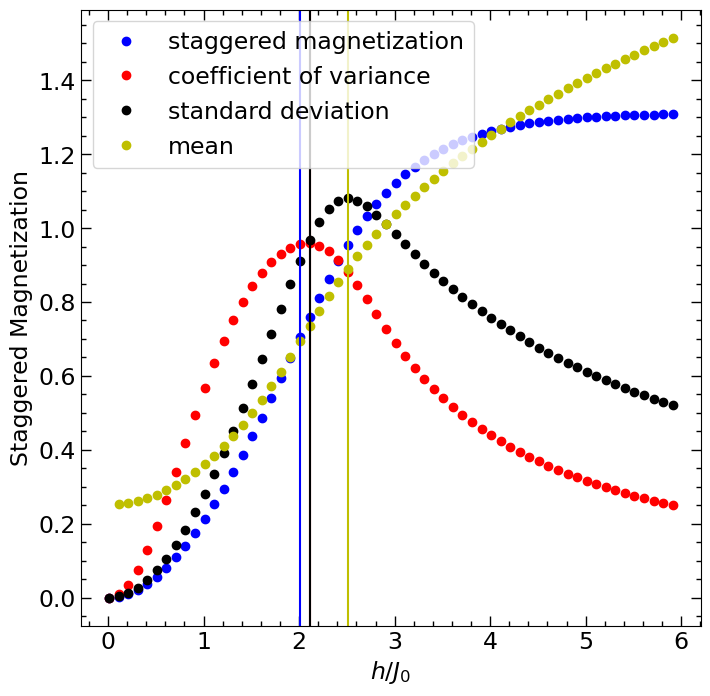

In [98]:
fig, ax = plt.subplots(figsize=(8,8))
plt.rcParams.update({'font.size': 17})
# label the axes
ax.set_xlabel(r"$h/J_0$")
ax.set_ylabel(r"Staggered Magnetization")

# set the tick mark parameters
ax.minorticks_on()
ax.tick_params(which='both',direction="in",width=1)
ax.tick_params(which='major',length=7)
ax.tick_params(which='minor',length=3.5)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

# p1 = plt.plot(np.arange(0.01, 6, 0.1), plotlist, 'ob', label = 'staggered magnetization')
# p2 = plt.plot(np.arange(0.01, 6, 0.1), values1, 'or', label = 'coefficient of variance')
# p3 = plt.plot(np.arange(0.01, 6, 0.1), values2, 'ok', label = 'standard deviation')
# p4 = plt.plot(np.arange(0.11, 6, 0.1), values3[-59:], 'oy', label = 'mean')
p1 = plt.plot(np.arange(0.01, 6, 0.1), newvalues1, 'ob', label = 'staggered magnetization')
p2 = plt.plot(np.arange(0.01, 6, 0.1), newvalues2, 'or', label = 'coefficient of variance')
p3 = plt.plot(np.arange(0.01, 6, 0.1), newvalues3, 'ok', label = 'standard deviation')
p4 = plt.plot(np.arange(0.11, 6, 0.1), newvalues4[-59:], 'oy', label = 'mean')

transition1 = plt.axvline(x=2.01, color='b')
transtion2 = plt.axvline(x=2.11, color='r')
transition3 = plt.axvline(x=2.11, color='k')
transition4 = plt.axvline(x=2.51, color='y')
plt.legend()
#plt.savefig("Degen 4 Glass Model Ratio With Varied h New.pdf")
plt.show()